# US Rates & Inflation Dashboard

Tracks the Fed funds effective rate, the 10-year US Treasury yield, and US CPI inflation against the Federal Reserve's 2% target — the three numbers that between them summarise where US monetary policy actually stands.

### US Fed funds effective rate

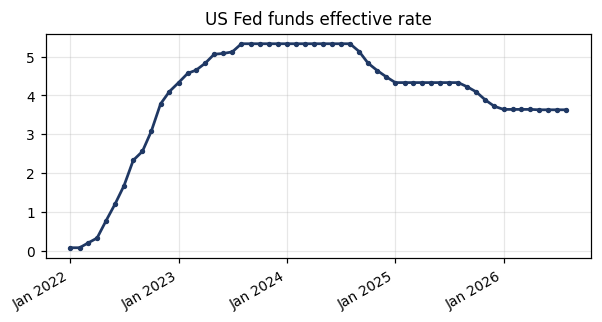

In [1]:
# chart

*Source: FRED — FEDFUNDS*

**Code:**
```python
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(us_ff["date"], us_ff["fed_funds_rate"], color="#1F3864", lw=1.8, marker="o", markersize=2.5)
ax.set_title("US Fed funds effective rate", fontsize=11)
```

**What this shows:**

This is the Fed's main policy lever — the rate at which banks lend each other reserves overnight, and the anchor for the entire US dollar cost of capital, from credit card APRs to corporate borrowing to the discount rate used to value future equity earnings. A falling effective rate is the Fed easing policy, usually because it judges the labour market or growth needs support and inflation has cooled enough to allow it; a rate held steady despite market pressure to cut is the Fed signalling it isn't yet convinced disinflation is durable. The pace of the decline here — gradual, not front-loaded — is itself informative about how cautious the Fed has been about declaring victory on inflation.

### US 10-year Treasury yield

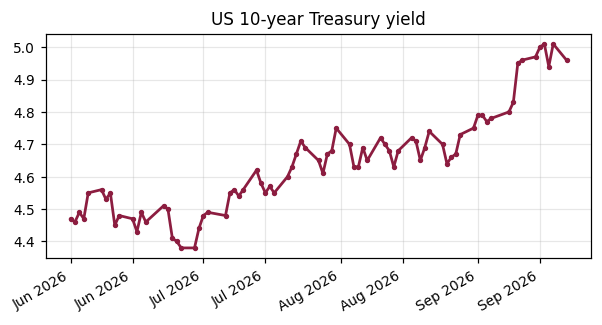

In [1]:
# chart

*Source: US Treasury daily par yield curve, pulled month by month via the Treasury's public XML feed*

**Code:**
```python
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(ust["date"], ust["y10"], color="#8C1D40", lw=1.8, marker="o", markersize=2.5)
ax.set_title("US 10-year Treasury yield", fontsize=11)
```

**What this shows:**

The 10-year Treasury yield is arguably the single most-watched number in global finance, because so much else is priced relative to it — mortgage rates, corporate borrowing costs, and (via the discount rate used in a DCF) equity valuations generally. Unlike the Fed funds rate, which the Fed sets directly, the 10-year is set by the market and reflects expected average short rates over the next decade plus a term premium, so it can rise even while the Fed is cutting if the market expects fewer future cuts than previously priced, or demands more compensation for holding long-dated government debt. That's exactly the dynamic behind the curve steepening tracked in the companion policy-surprise notebook.

### US CPI, year-on-year

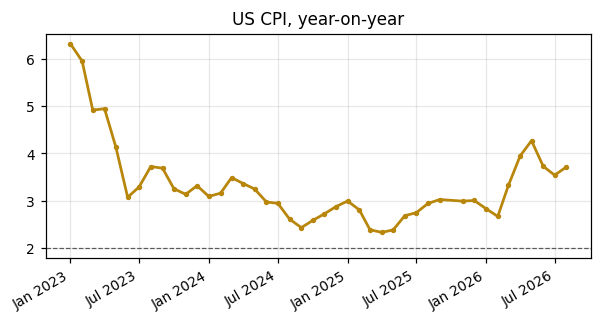

In [1]:
# chart

*Source: FRED — CPIAUCSL*

**Code:**
```python
us_cpi["yoy"] = us_cpi["cpi_index"].pct_change(12) * 100
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(us_cpi["date"], us_cpi["yoy"], color="#B8860B", lw=1.8, marker="o", markersize=2.5)
ax.axhline(2.0, color="#595959", ls="--", lw=0.8)
ax.set_title("US CPI, year-on-year", fontsize=11)
```

**What this shows:**

The dashed line is the Fed's 2% target. CPI running above it for an extended period is the standard justification for the Fed holding rates higher for longer than the market would like; a clean, sustained move toward target is what would let the Fed cut with more confidence. What matters in practice is less the single print and more the trend — a series that keeps bouncing around the mid-3% area without a clear downward slope, as it does for stretches here, is the kind of ambiguous read that tends to produce split opinions on the Federal Open Market Committee rather than a clean consensus either way.

## Caveats on the data behind this notebook

**The Treasury yield-curve window covers 1 June – 21 September 2026,** pulled from the Treasury's public XML feed one calendar month at a time — a single request against that feed is capped well short of a full year by its own pagination, so this was built up month by month rather than in one pull. Anything before June 2026 simply isn't in this dataset.

**US CPI and Fed funds are monthly series**, so the most recent 2-3 weeks of any given month won't yet be reflected in the CPI/Fed funds charts even though the Treasury yield chart may already extend past it.